Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



🔹 Box 1 (Class 99):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 85)
  ② Word candidate:   'ঠাকুরগাঁও' (fuzzy: 88, conf: 35)
  ⭐ Final: '১১৪১১৪' [number] (score: 85)


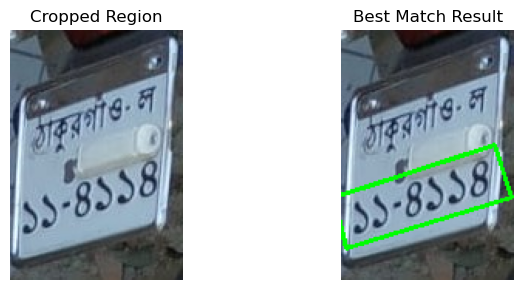


🔹 Box 2 (Class 25):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 62)
  ② Word candidate:   None
  ⭐ Final: '১১৪১১৪' [number] (score: 62)


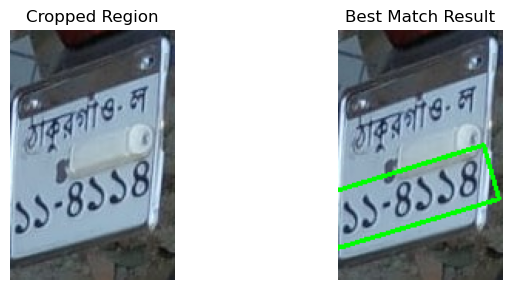


🔹 Box 3 (Class 1):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 81)
  ② Word candidate:   None
  ⭐ Final: '১১৪১১৪' [number] (score: 81)


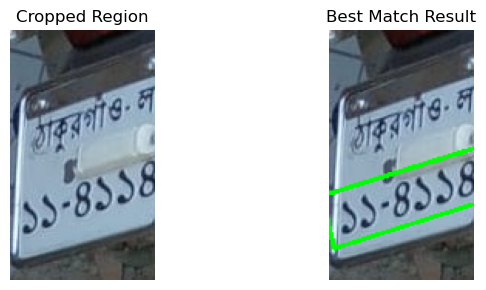


🔹 Box 4 (Class 1):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 53)
  ② Word candidate:   'ঠাকুরগাঁও' (fuzzy: 82, conf: 48)
  ⭐ Final: 'ঠাকুরগাঁও' [word] (score: 65)


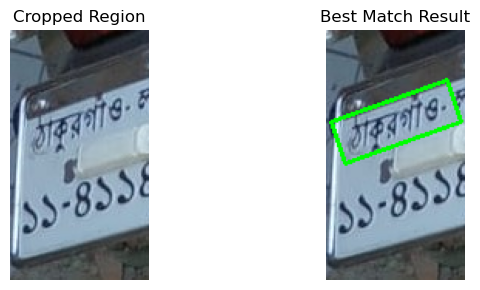


🔹 Box 5 (Class 1):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 85)
  ② Word candidate:   'ঠাকুরগাঁও' (fuzzy: 88, conf: 35)
  ⭐ Final: '১১৪১১৪' [number] (score: 85)


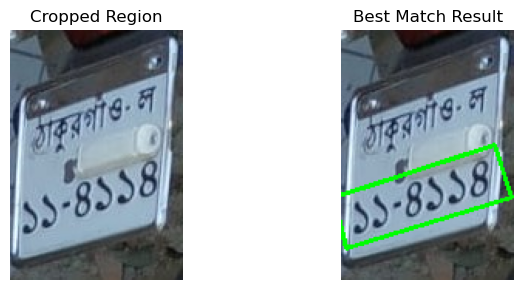


🔹 Box 6 (Class 1):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 76)
  ② Word candidate:   None
  ⭐ Final: '১১৪১১৪' [number] (score: 76)


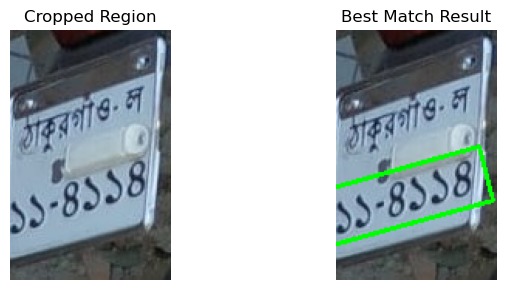


🔹 Box 7 (Class 4):
  ① Number candidate: '৪১১৪' (digits: 4, conf: 43)
  ② Word candidate:   None
  ⭐ Final: '৪১১৪' [number] (score: 43)


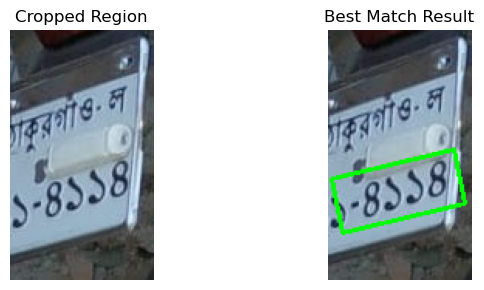


🔹 Box 8 (Class 4):
  ① Number candidate: '১১৪১১৪' (digits: 6, conf: 85)
  ② Word candidate:   'ঠাকুরগাঁও' (fuzzy: 88, conf: 35)
  ⭐ Final: '১১৪১১৪' [number] (score: 85)


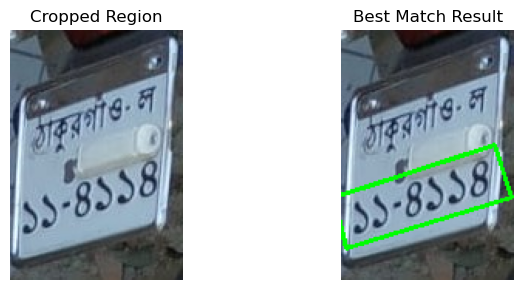


================ Global Summary ================
Most frequent number: '১১৪১১৪' (count: 7)
Most frequent word:   'ঠাকুরগাঁও' (count: 4)
Most frequent final:  '১১৪১১৪' (count: 6)

✅ Final Answer (most frequent word + number): ঠাকুরগাঁও ১১৪১১৪


In [22]:
import cv2
import easyocr
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Robust fuzzy matching: try rapidfuzz, then thefuzz, then fallback to difflib
try:
    from rapidfuzz import process as _rf_process
    def extract_one(query, choices):
        res = _rf_process.extractOne(query, choices, score_cutoff=0)
        if res:
            return res[0], int(res[1])
        return None
except Exception:
    try:
        from thefuzz import process as _tf_process
        def extract_one(query, choices):
            res = _tf_process.extractOne(query, choices)
            if res:
                return res[0], int(res[1])
            return None
    except Exception:
        import difflib
        def extract_one(query, choices):
            best_word, best_score = None, -1
            for c in choices:
                s = int(difflib.SequenceMatcher(None, query, c).ratio() * 100)
                if s > best_score:
                    best_score = s
                    best_word = c
            return (best_word, best_score) if best_word is not None else None

# === CONFIGURATION ===
image_path = "test.jpeg"
label_path = "test.txt"
output_dir = "outputs"
PADDING_PERCENT = 10
SIMILARITY_THRESHOLD = 80  # Fuzzy match threshold for valid words

# Whitelist for valid text
valid_words_set = {
    "ঢাকা", "গাজীপুর", "কিশোরগঞ্জ", "মানিকগঞ্জ", "মুন্সিগঞ্জ", "নারায়ণগঞ্জ", "নরসিংদী", "টাঙ্গাইল",
    "ফরিদপুর", "গোপালগঞ্জ", "মাদারীপুর", "রাজবাড়ী", "শরীয়তপুর", "চট্টগ্রাম", "কক্সবাজার", "রাঙামাটি",
    "বান্দরবান", "খাগড়াছড়ি", "ফেনী", "নোয়াখালী", "লক্ষ্মীপুর", "চাঁদপুর", "ব্রাহ্মণবাড়িয়া", "কুমিল্লা",
    "খুলনা", "বাগেরহাট", "সাতক্ষীরা", "যশোর", "ঝিনাইদহ", "মাগুরা", "নড়াইল", "কুষ্টিয়া",
    "চুয়াডাঙ্গা", "মেহেরপুর", "রাজশাহী", "চাঁপাইনবাবগঞ্জ", "নওগাঁ", "নাটোর", "পাবনা", "সিরাজগঞ্জ",
    "বগুড়া", "জয়পুরহাট", "রংপুর", "দিনাজপুর", "কুড়িগ্রাম", "গাইবান্ধা", "নীলফামারী", "লালমনিরহাট",
    "ঠাকুরগাঁও", "পঞ্চগড়", "বরিশাল", "ভোলা", "পটুয়াখালী", "বরগুনা", "ঝালকাঠি", "পিরোজপুর",
    "সিলেট", "মৌলভীবাজার", "হবিগঞ্জ", "সুনামগঞ্জ", "ময়মনসিংহ", "নেত্রকোনা", "জামালপুর", "শেরপুর",
    "মেট্রো", "উত্তর", "দক্ষিণ"
}

# Helper functions
bangla_digits = "০১২৩৪৫৬৭৮৯"

def is_bangla_number(text: str) -> bool:
    if not text:
        return False
    return any(ch in bangla_digits for ch in text)

def only_bangla_digits(text: str) -> str:
    return "".join(ch for ch in text if ch in bangla_digits)

def better_numeric(a, b):
    """Choose better numeric candidate: prefer more digits, then higher prob."""
    if a is None:
        return b
    if b is None:
        return a
    if a['digits_len'] != b['digits_len']:
        return a if a['digits_len'] > b['digits_len'] else b
    return a if a['prob'] >= b['prob'] else b

def better_word(a, b):
    """Choose better word candidate: prefer higher fuzzy score, then higher prob."""
    if a is None:
        return b
    if b is None:
        return a
    if a['fuzzy'] != b['fuzzy']:
        return a if a['fuzzy'] > b['fuzzy'] else b
    return a if a['prob'] >= b['prob'] else b

def final_choice(numeric_best, word_best):
    """Pick the best single output between numeric and word candidates.
    Score:
      - numeric_conf = prob * 100
      - word_conf = 0.5 * fuzzy + 0.5 * (prob * 100)
    Returns tuple (chosen_label, chosen_score, chosen_bbox, chosen_type)
    """
    if numeric_best is None and word_best is None:
        return None
    num_conf = numeric_best['prob'] * 100 if numeric_best else -1
    word_conf = (0.5 * word_best['fuzzy'] + 0.5 * (word_best['prob'] * 100)) if word_best else -1
    if num_conf >= word_conf:
        return (numeric_best['text'], num_conf, numeric_best['bbox'], 'number')
    else:
        return (word_best['text'], word_conf, word_best['bbox'], 'word')

# Make output directory if not exist
os.makedirs(output_dir, exist_ok=True)
results_log_path = os.path.join(output_dir, "ocr_text_results.txt")

# reset log file
with open(results_log_path, "w", encoding="utf-8") as lf:
    lf.write("Bangla OCR results per box (two candidates + final)\n")

# === STEP 1: Initialize EasyOCR Reader ===
reader = easyocr.Reader(['bn'])

# If inputs are missing, don't crash the notebook
if not os.path.exists(image_path):
    print(f"Image not found: {image_path}. Update image_path and re-run.")
elif not os.path.exists(label_path):
    print(f"Label file not found: {label_path}. Update label_path and re-run.")
else:
    # === STEP 2: Read image ===
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
    else:
        h_img, w_img = img.shape[:2]

        # === STEP 3: Read YOLO labels ===
        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        # Global frequency trackers
        numeric_counts = Counter()  # text -> count
        word_counts = Counter()     # text -> count
        final_counts = Counter()    # text -> count (for the final chosen label)

        # === STEP 4: Loop through each label and crop region ===
        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, x, y, w, h = map(float, parts)

            x_center, y_center, w_box, h_box = x * w_img, y * h_img, w * w_img, h * h_img
            w_box_padded, h_box_padded = w_box * (1 + PADDING_PERCENT), h_box * (1 + PADDING_PERCENT)
            x1, y1 = int(x_center - w_box_padded / 2), int(y_center - h_box_padded / 2)
            x2, y2 = int(x_center + w_box_padded / 2), int(y_center + h_box_padded / 2)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w_img, x2), min(h_img, y2)

            cropped = img[y1:y2, x1:x2]

            if cropped.size == 0:
                print(f"\n🔹 Box {i+1} resulted in an empty crop. Skipping.")
                with open(results_log_path, "a", encoding="utf-8") as lf:
                    lf.write(f"Box {i+1}: Empty crop, skipped.\n")
                continue

            # === STEP 5: Run OCR ===
            raw_result = reader.readtext(cropped)  # list of (bbox, text, prob)

            # Track two independent bests
            numeric_best = None  # {'text', 'digits_len', 'prob', 'bbox'}
            word_best = None     # {'text', 'fuzzy', 'prob', 'bbox'}

            for (bbox, text, prob) in raw_result:
                clean_text = text.strip()
                if not clean_text:
                    continue

                # Candidate 1: Bangla number
                if is_bangla_number(clean_text):
                    digits = only_bangla_digits(clean_text)
                    if digits:
                        cand = {
                            'text': digits,
                            'digits_len': len(digits),
                            'prob': float(prob),
                            'bbox': bbox
                        }
                        numeric_best = better_numeric(numeric_best, cand)

                # Candidate 2: Valid word via fuzzy match
                res = extract_one(clean_text, valid_words_set)
                if res:
                    matched_word, sim = res
                    if sim >= SIMILARITY_THRESHOLD:
                        cand = {
                            'text': matched_word,
                            'fuzzy': int(sim),
                            'prob': float(prob),
                            'bbox': bbox
                        }
                        word_best = better_word(word_best, cand)

            # Prepare console output
            print(f"\n🔹 Box {i+1} (Class {int(cls)}):")
            if numeric_best:
                print(f"  ① Number candidate: '{numeric_best['text']}' (digits: {numeric_best['digits_len']}, conf: {numeric_best['prob']*100:.0f})")
                numeric_counts[numeric_best['text']] += 1
            else:
                print("  ① Number candidate: None")

            if word_best:
                print(f"  ② Word candidate:   '{word_best['text']}' (fuzzy: {word_best['fuzzy']}, conf: {word_best['prob']*100:.0f})")
                word_counts[word_best['text']] += 1
            else:
                print("  ② Word candidate:   None")

            final_sel = final_choice(numeric_best, word_best)
            if final_sel:
                final_text, final_score, final_bbox, final_type = final_sel
                print(f"  ⭐ Final: '{final_text}' [{final_type}] (score: {final_score:.0f})")
                final_counts[final_text] += 1
            else:
                final_text, final_bbox, final_type = None, None, None
                print("  No valid candidates found.")

            # Append to log file
            with open(results_log_path, "a", encoding="utf-8") as lf:
                lf.write(f"Box {i+1} (Class {int(cls)}):\n")
                lf.write(f"  Number: {numeric_best['text']}\n" if numeric_best else "  Number: None\n")
                lf.write(f"  Word:   {word_best['text']}\n" if word_best else "  Word:   None\n")
                lf.write(f"  Final:  {final_text if final_text else 'None'}\n\n")

            # === STEP 6: Display visualization ===
            plt.figure(figsize=(8, 3))
            plt.subplot(1, 2, 1)
            plt.title("Cropped Region")
            plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.title("Best Match Result")
            display_img = cropped.copy()
            if final_sel and final_bbox:
                pts = [tuple(map(int, point)) for point in final_bbox]
                cv2.polylines(display_img, [np.array(pts)], True, (0, 255, 0), 2)  # green for final

            plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
            plt.axis("off")

            plt.tight_layout()
            plt.show()

        # === STEP 7: Global frequency summary ===
        print("\n================ Global Summary ================")
        top_num = numeric_counts.most_common(1)[0] if numeric_counts else None
        top_word = word_counts.most_common(1)[0] if word_counts else None
        top_final = final_counts.most_common(1)[0] if final_counts else None

        if top_num:
            print(f"Most frequent number: '{top_num[0]}' (count: {top_num[1]})")
        else:
            print("Most frequent number: None")

        if top_word:
            print(f"Most frequent word:   '{top_word[0]}' (count: {top_word[1]})")
        else:
            print("Most frequent word:   None")

        if top_final:
            print(f"Most frequent final:  '{top_final[0]}' (count: {top_final[1]})")
        else:
            print("Most frequent final:  None")

        # Combined final answer: word + number (if both available)
        combined_final = None
        if top_word and top_num:
            combined_final = f"{top_word[0]} {top_num[0]}"
            print(f"\n✅ Final Answer (most frequent word + number): {combined_final}")
        elif top_word:
            combined_final = top_word[0]
            print(f"\n✅ Final Answer (word): {combined_final}")
        elif top_num:
            combined_final = top_num[0]
            print(f"\n✅ Final Answer (number): {combined_final}")
        else:
            print("\n✅ Final Answer: None")

        with open(results_log_path, "a", encoding="utf-8") as lf:
            lf.write("================ Global Summary ================\n")
            lf.write(f"Most frequent number: {top_num[0]} ({top_num[1]})\n" if top_num else "Most frequent number: None\n")
            lf.write(f"Most frequent word:   {top_word[0]} ({top_word[1]})\n" if top_word else "Most frequent word:   None\n")
            lf.write(f"Most frequent final:  {top_final[0]} ({top_final[1]})\n" if top_final else "Most frequent final:  None\n")
            if combined_final:
                lf.write(f"Final Answer: {combined_final}\n")
            else:
                lf.write("Final Answer: None\n")